In [1]:
# 06 – Finale Visualisierungen fuer Praesentation
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

PROCESSED = Path('..') / 'data' / 'processed'
OUTPUTS   = Path('..') / 'outputs' / 'maps'
OUTPUTS.mkdir(parents=True, exist_ok=True)

# Alle Daten laden
gdf_gem = gpd.read_file(PROCESSED / 'gemeinden_mit_distanz.gpkg')
gdf_pharm = gpd.read_file(PROCESSED / 'pharmacies_ch.geojson').to_crs(2056)
gdf_kant  = gpd.read_file(Path('..') / 'data' / 'raw' / 'kantone_ch_lv95.geojson').to_crs(2056)

print('Alle Daten geladen:')
print('- Gemeinden:  ', len(gdf_gem))
print('- Apotheken:  ', len(gdf_pharm))
print('- Kantone:    ', len(gdf_kant))

Alle Daten geladen:
- Gemeinden:   2123
- Apotheken:   1640
- Kantone:     11


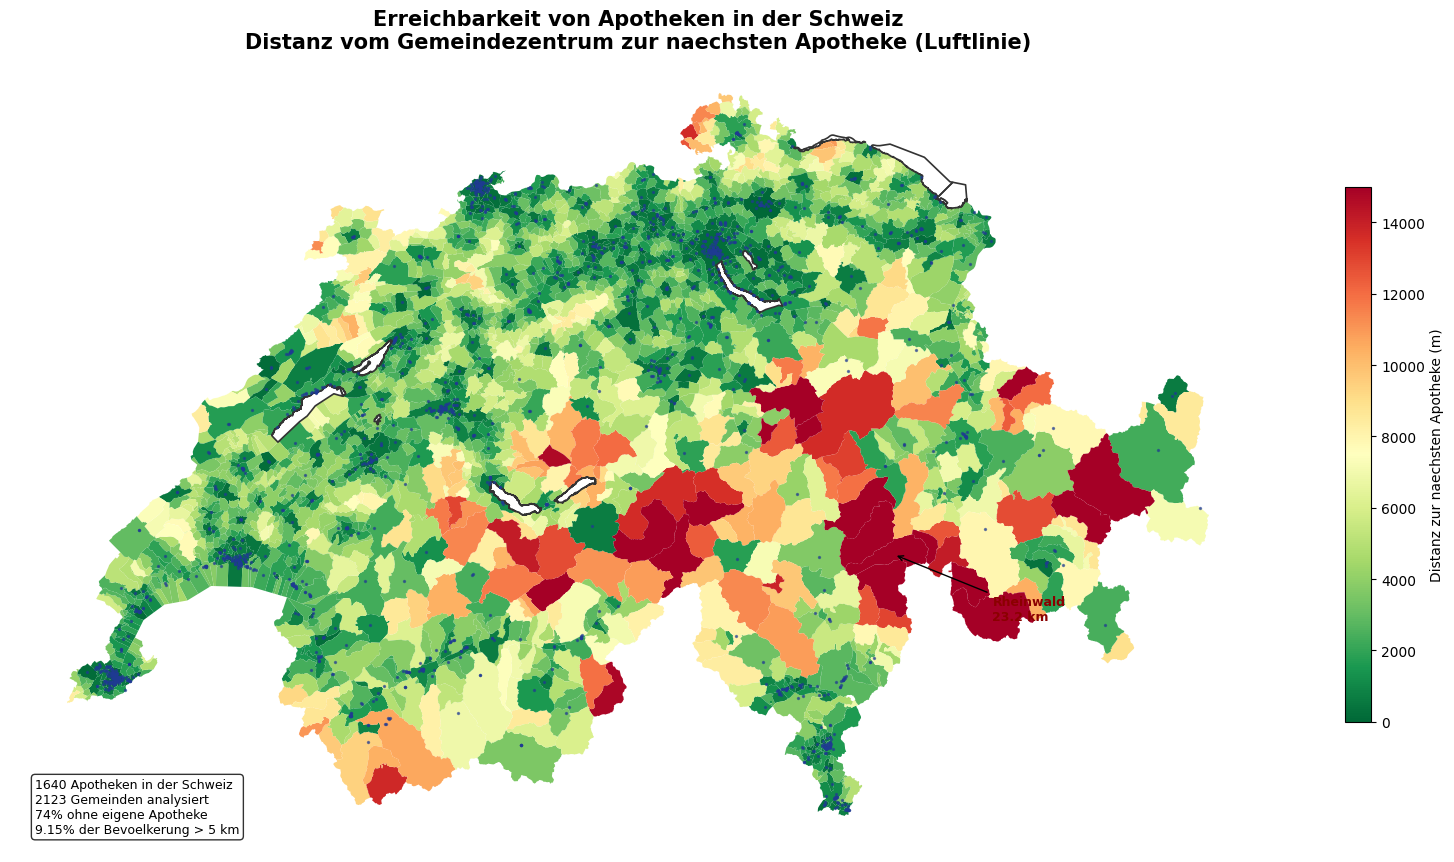

Hauptkarte gespeichert: ..\outputs\maps\06_hauptkarte_distanz.png


In [2]:
# 2) Hauptkarte: Distanz zur naechsten Apotheke – Praesentation-Version
fig, ax = plt.subplots(figsize=(16, 11))

gdf_gem.plot(
    column='min_distanz_m', ax=ax,
    cmap='RdYlGn_r', vmin=0, vmax=15000,
    legend=True,
    legend_kwds={'label': 'Distanz zur naechsten Apotheke (m)',
                 'shrink': 0.5, 'orientation': 'vertical'}
)
gdf_kant.boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=3)
gdf_pharm.plot(ax=ax, color='#1f3a93', markersize=2, alpha=0.6, zorder=4)

# Schlechtestversorgte Gemeinde annotieren
worst = gdf_gem.nlargest(1, 'min_distanz_m').iloc[0]
cx, cy = worst.geometry.centroid.x, worst.geometry.centroid.y
ax.annotate(f"{worst['name']}\n{worst['min_distanz_m']/1000:.1f} km",
            xy=(cx, cy), xytext=(cx+30000, cy-20000),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, fontweight='bold', color='darkred')

ax.set_title('Erreichbarkeit von Apotheken in der Schweiz\n'
             'Distanz vom Gemeindezentrum zur naechsten Apotheke (Luftlinie)',
             fontsize=15, fontweight='bold')
ax.set_axis_off()

# Statistik-Box
stats_text = (
    f'1640 Apotheken in der Schweiz\n'
    f'2123 Gemeinden analysiert\n'
    f'74% ohne eigene Apotheke\n'
    f'9.15% der Bevoelkerung > 5 km'
)
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
out = OUTPUTS / '06_hauptkarte_distanz.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print('Hauptkarte gespeichert:', out)

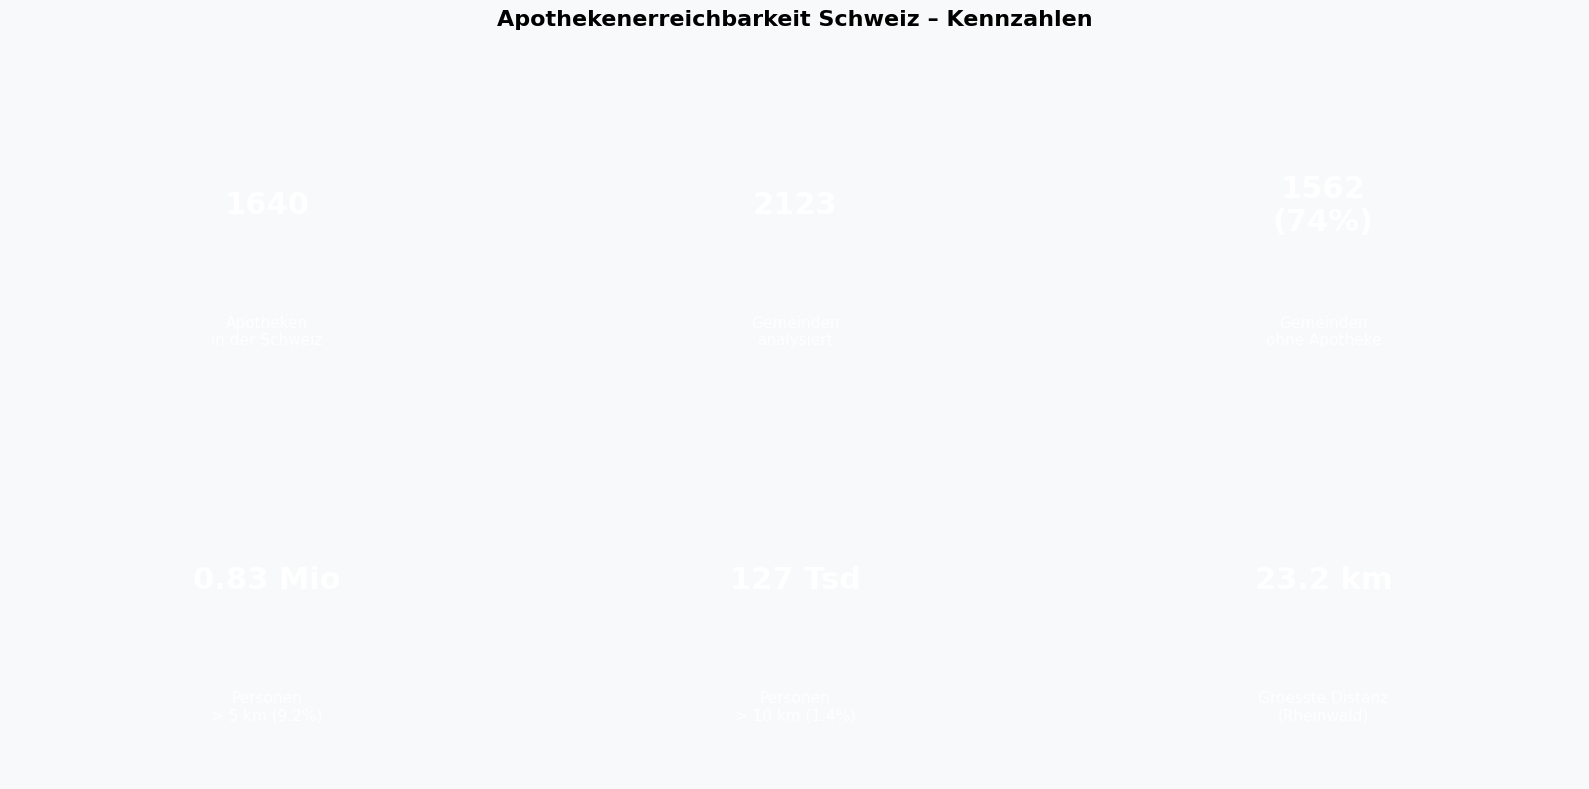

Dashboard gespeichert: ..\outputs\maps\06_kennzahlen_dashboard.png


In [3]:
# 3) Kennzahlen-Dashboard fuer Slides
total_bev = gdf_gem['einwohnerzahl'].sum()
bev_5km   = gdf_gem[gdf_gem['min_distanz_m'] > 5000]['einwohnerzahl'].sum()
bev_10km  = gdf_gem[gdf_gem['min_distanz_m'] > 10000]['einwohnerzahl'].sum()
gem_ohne  = (gdf_gem['apotheken_anzahl'] == 0).sum()
max_dist  = gdf_gem['min_distanz_m'].max()
worst_gem = gdf_gem.nlargest(1, 'min_distanz_m').iloc[0]['name']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#f8f9fa')

kennzahlen = [
    ('1640', 'Apotheken\nin der Schweiz', '#2ecc71'),
    ('2123', 'Gemeinden\nanalysiert', '#3498db'),
    (f'{gem_ohne}\n(74%)', 'Gemeinden\nohne Apotheke', '#e74c3c'),
    (f'{bev_5km/1e6:.2f} Mio', f'Personen\n> 5 km ({bev_5km/total_bev*100:.1f}%)', '#e67e22'),
    (f'{bev_10km/1e3:.0f} Tsd', f'Personen\n> 10 km ({bev_10km/total_bev*100:.1f}%)', '#c0392b'),
    (f'{max_dist/1000:.1f} km', f'Groesste Distanz\n({worst_gem})', '#8e44ad'),
]

for ax, (wert, label, farbe) in zip(axes.flat, kennzahlen):
    ax.set_facecolor(farbe)
    ax.text(0.5, 0.55, wert, transform=ax.transAxes,
            fontsize=22, fontweight='bold', color='white',
            ha='center', va='center')
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            fontsize=11, color='white', ha='center', va='center')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()

plt.suptitle('Apothekenerreichbarkeit Schweiz – Kennzahlen', fontsize=16, fontweight='bold', color='#1A2840')
plt.tight_layout()
out = OUTPUTS / '06_kennzahlen_dashboard.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard gespeichert:', out)

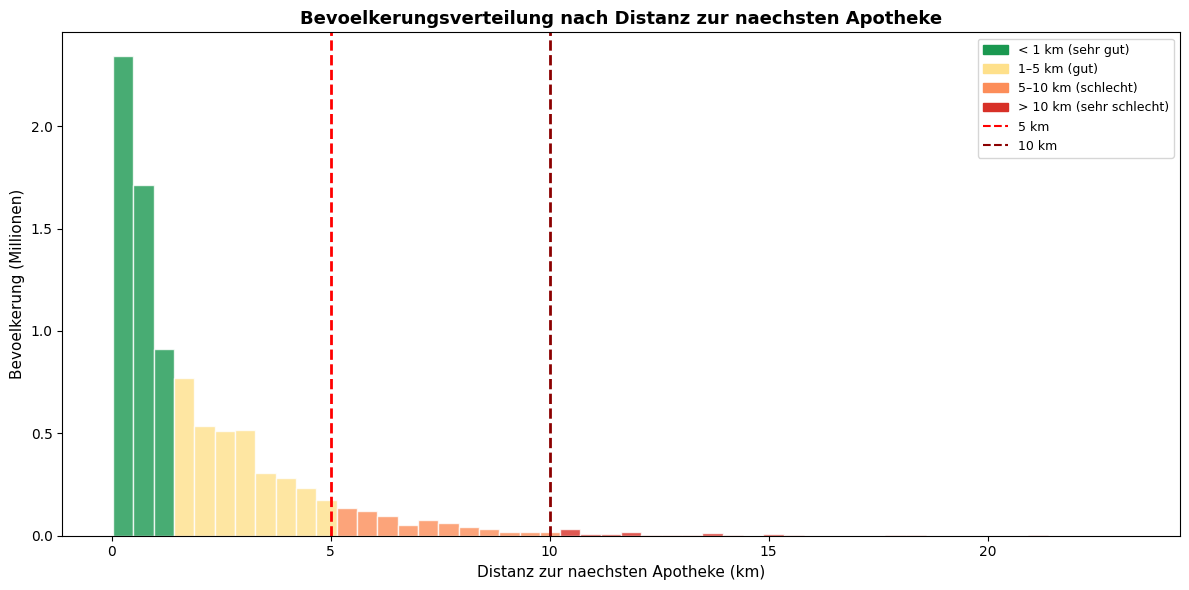

Histogramm gespeichert: ..\outputs\maps\06_distanz_histogramm.png


In [4]:
# 4) Distanz-Histogramm bevoelkerungsgewichtet
fig, ax = plt.subplots(figsize=(12, 6))

# Bevoelkerungsgewichtetes Histogramm
distances_km = gdf_gem['min_distanz_m'] / 1000
weights = gdf_gem['einwohnerzahl']

n, bins, patches = ax.hist(distances_km, bins=50, weights=weights/1e6,
                            color='#3498db', edgecolor='white', alpha=0.8)

# Einfaerben nach Versorgungsklasse
for patch, left in zip(patches, bins[:-1]):
    if left < 1:   patch.set_facecolor('#1a9850')
    elif left < 5: patch.set_facecolor('#fee08b')
    elif left < 10:patch.set_facecolor('#fc8d59')
    else:          patch.set_facecolor('#d73027')

ax.axvline(x=5, color='red', linestyle='--', linewidth=2, label='5 km Schwelle')
ax.axvline(x=10, color='darkred', linestyle='--', linewidth=2, label='10 km Schwelle')

ax.set_title('Bevoelkerungsverteilung nach Distanz zur naechsten Apotheke',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Distanz zur naechsten Apotheke (km)', fontsize=11)
ax.set_ylabel('Bevoelkerung (Millionen)', fontsize=11)
ax.legend(fontsize=10)

legend_elements = [
    mpatches.Patch(color='#1a9850', label='< 1 km (sehr gut)'),
    mpatches.Patch(color='#fee08b', label='1–5 km (gut)'),
    mpatches.Patch(color='#fc8d59', label='5–10 km (schlecht)'),
    mpatches.Patch(color='#d73027', label='> 10 km (sehr schlecht)'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0],color='red',linestyle='--',label='5 km'),
                                      plt.Line2D([0],[0],color='darkred',linestyle='--',label='10 km')],
          fontsize=9)
plt.tight_layout()
out = OUTPUTS / '06_distanz_histogramm.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Histogramm gespeichert:', out)

In [5]:
# 5) Alle Outputs pruefen
print('=== ALLE OUTPUTS ===')
alle = sorted(OUTPUTS.glob('*.png'))
for p in alle:
    print(f'  OK  {p.name:<45} {p.stat().st_size/1024:.0f} KB')
print(f'\nTotal: {len(alle)} Karten/Grafiken')
print('\nProjekt abgeschlossen! Bereit fuer Slides.')

=== ALLE OUTPUTS ===
  OK  01_apotheken_uebersicht.png                   605 KB
  OK  02_distanz_apotheke.png                       963 KB
  OK  03_einzeltest_isochrone.png                   216 KB
  OK  03_isochronen_5min_auto.png                   629 KB
  OK  04_boxplot_kantone.png                        77 KB
  OK  04_lisa_cluster.png                           491 KB
  OK  04_zuerich_quartiere.png                      242 KB
  OK  05_bevoelkerungsabdeckung.png                 94 KB
  OK  05_unterversorgte_gemeinden.png               687 KB
  OK  06_distanz_histogramm.png                     56 KB
  OK  06_hauptkarte_distanz.png                     1186 KB
  OK  06_hauptkarte_distanz_final.png               934 KB
  OK  06_kennzahlen_dashboard.png                   52 KB

Total: 13 Karten/Grafiken

Projekt abgeschlossen! Bereit fuer Slides.
